<a href="https://colab.research.google.com/github/Balamurugan-T326/Machine-Learning/blob/main/Experiment-6/scenario-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
data = pd.read_csv("/content/diabetes_bagging.csv")
data.head()

,Glucose,BMI,Age,BloodPressure,Insulin,Outcome
0,182,21.1,45,99,100,1
1,131,35.6,67,92,199,1
2,172,19.6,68,68,234,1
3,94,39.7,21,102,83,0
4,186,35.0,20,113,61,1


In [3]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


In [6]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)
bag_accuracy = accuracy_score(y_test, y_pred_bag)

print("Bagging Accuracy:", bag_accuracy)

Bagging Accuracy: 1.0


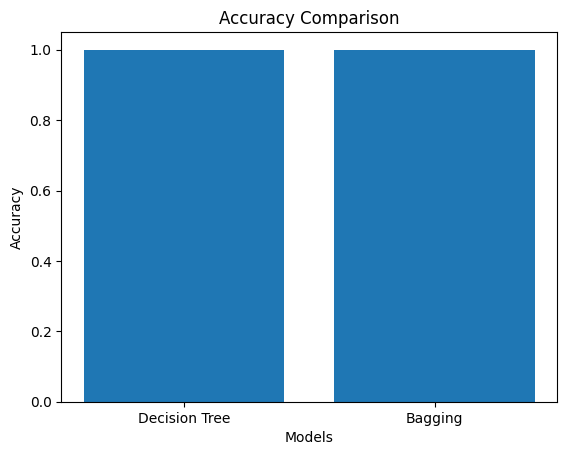

In [7]:
models = ['Decision Tree', 'Bagging']
accuracies = [dt_accuracy, bag_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

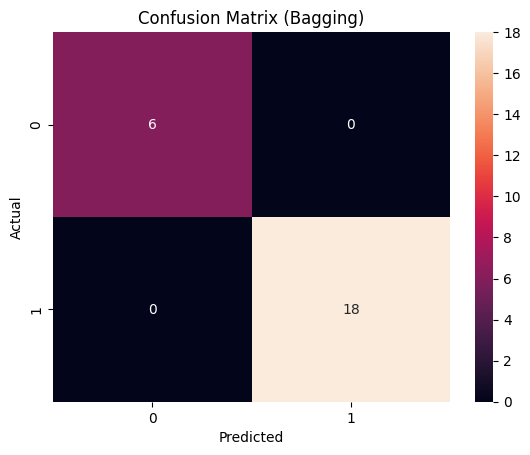

In [8]:
cm = confusion_matrix(y_test, y_pred_bag)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Bagging)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()